## Tasks

### Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights.

**Part B — Shape tracking.**

Build the following CNN block and verify shapes:

```python
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
```

1. Create a dummy input `x = torch.randn(8, 3, 32, 32)`.
2. Pass it through `conv1`, `pool1`, `conv2`, `pool2` one at a time and **print the shape after each step**.
3. Fill in this table:

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | … |
| pool1 | … | … |
| conv2 | … | … |
| pool2 | … | … |


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [2]:
#image load + tensor
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

transform = transforms.ToTensor()

cifar = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
img, label = cifar[0]

# shape: (1, 3, 32, 32)
img = img.unsqueeze(0)
print(img.shape)

torch.Size([1, 3, 32, 32])


In [3]:
#Filter
import torch.nn as nn

conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

# vertical edge
vertical = torch.tensor([
    [[-1,0,1],
     [-1,0,1],
     [-1,0,1]],
]*3).unsqueeze(0).float()

conv.weight.data = vertical
out_v = conv(img)

# horizontal
horizontal = vertical.transpose(2,3)
conv.weight.data = horizontal
out_h = conv(img)

# blur
blur = (torch.ones(3,3)/9).repeat(3,1,1).unsqueeze(0)
conv.weight.data = blur
out_b = conv(img)

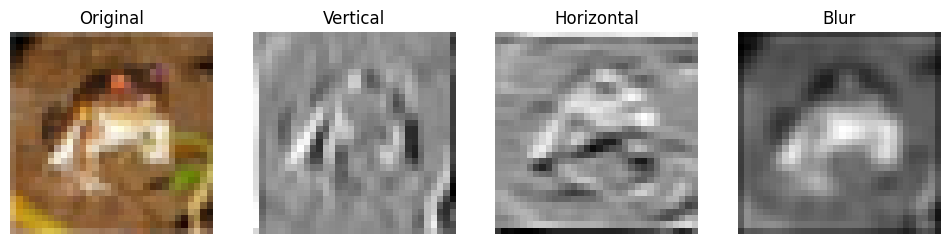

In [4]:
# visualization
def show(img, out_v, out_h, out_b):
    fig, ax = plt.subplots(1,4, figsize=(12,3))

    ax[0].imshow(img.squeeze().permute(1,2,0))
    ax[0].set_title("Original")

    ax[1].imshow(out_v.squeeze().detach(), cmap="gray")
    ax[1].set_title("Vertical")

    ax[2].imshow(out_h.squeeze().detach(), cmap="gray")
    ax[2].set_title("Horizontal")

    ax[3].imshow(out_b.squeeze().detach(), cmap="gray")
    ax[3].set_title("Blur")

    for a in ax: a.axis("off")

show(img, out_v, out_h, out_b)

In [5]:
#B shape tracking
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv1(x)
        print("conv1:", x.shape)

        x = self.pool1(x)
        print("pool1:", x.shape)

        x = self.conv2(x)
        print("conv2:", x.shape)

        x = self.pool2(x)
        print("pool2:", x.shape)
        return x

model = TinyCNN()
x = torch.randn(8,3,32,32)
_ = model(x)

conv1: torch.Size([8, 16, 32, 32])
pool1: torch.Size([8, 16, 16, 16])
conv2: torch.Size([8, 32, 16, 16])
pool2: torch.Size([8, 32, 8, 8])



###  Part A — Handcrafted Filters

In this part, we applied manually designed convolution filters to a CIFAR-10 image to understand how convolution operations extract different visual features.

* The **vertical edge detector** highlights vertical structures in the image by detecting strong intensity changes along the horizontal direction. This helps in identifying object boundaries such as edges of buildings, objects, or shapes.

* The **horizontal edge detector** performs a similar operation but focuses on horizontal intensity changes. It emphasizes horizontal edges like horizons, surfaces, or layered structures.

* The **blur filter** averages neighboring pixel values, which reduces noise and removes sharp details. This results in a smoother version of the image and demonstrates how convolution can be used for image smoothing and preprocessing.

Overall, this experiment shows that convolution filters act as feature extractors that can be manually designed to detect specific patterns in images.

---

###  Part B — Shape Tracking in CNN

In this section, we tracked how the spatial dimensions of a tensor change as it passes through convolution and pooling layers.

* Convolution layers (with padding=1) preserve spatial dimensions while increasing the depth (number of channels), allowing the model to learn more feature maps.
* MaxPooling layers reduce the spatial dimensions by half, compressing the information while keeping the most important features.

This step-by-step tracking helps to understand how CNNs gradually transform an input image (32×32) into a compact feature representation while increasing the number of channels from 3 → 16 → 32.

By the end of the network, the image is converted into a small but information-rich feature map, which can then be used for classification tasks.


### Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).


In [6]:
#Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [7]:
#Parameter count
model = CNN()
sum(p.numel() for p in model.parameters() if p.requires_grad)

1117354

In [8]:
#Training loop (core)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
#DataLoader
train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
val_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=train_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

In [10]:
# Training loop
train_loss, val_loss = [], []
train_acc, val_acc = [], []

task2_best_val_acc = 0.0

for epoch in range(15):

    model.train()

    correct, total, loss_sum = 0, 0, 0

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        loss_sum += loss.item()

        preds = out.argmax(1)

        correct += (preds == y).sum().item()

        total += y.size(0)

    train_loss.append(loss_sum / len(train_loader))
    train_acc.append(correct / total)

    # validation
    model.eval()

    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():

        for x, y in val_loader:

            x, y = x.to(device), y.to(device)

            out = model(x)

            loss = criterion(out, y)

            loss_sum += loss.item()

            preds = out.argmax(1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    val_loss.append(loss_sum / len(val_loader))

    val_accuracy = correct / total
    val_acc.append(val_accuracy)

    # best validation accuracy
    if val_accuracy > task2_best_val_acc:
        task2_best_val_acc = val_accuracy

    print(f"Epoch {epoch+1}: train_acc={train_acc[-1]:.4f}, val_acc={val_accuracy:.4f}")

Epoch 1: train_acc=0.5015, val_acc=0.6291
Epoch 2: train_acc=0.6596, val_acc=0.6988
Epoch 3: train_acc=0.7121, val_acc=0.7287
Epoch 4: train_acc=0.7418, val_acc=0.7546
Epoch 5: train_acc=0.7685, val_acc=0.7619
Epoch 6: train_acc=0.7838, val_acc=0.7603
Epoch 7: train_acc=0.8026, val_acc=0.7860
Epoch 8: train_acc=0.8153, val_acc=0.7609
Epoch 9: train_acc=0.8293, val_acc=0.7828
Epoch 10: train_acc=0.8413, val_acc=0.7827
Epoch 11: train_acc=0.8530, val_acc=0.7857
Epoch 12: train_acc=0.8624, val_acc=0.7905
Epoch 13: train_acc=0.8743, val_acc=0.7969
Epoch 14: train_acc=0.8797, val_acc=0.7930
Epoch 15: train_acc=0.8881, val_acc=0.8007


In [22]:
print("Task 2 Best Validation Accuracy:", task2_best_val_acc)

Task 2 Best Validation Accuracy: 0.8007


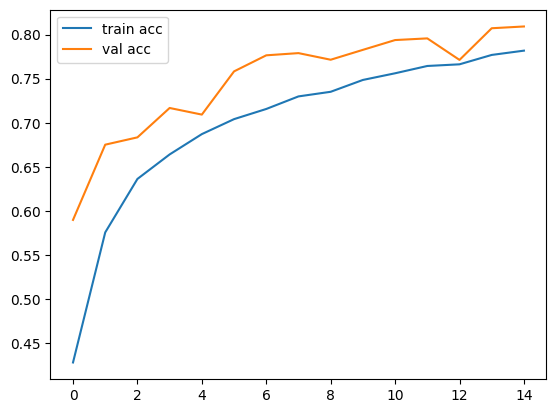

In [23]:
#Plot
plt.plot(train_acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.legend()
plt.show()

### Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.

In [24]:
#step 1. Tranining transform
import torchvision.transforms as transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [25]:
#2. Validation transform
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [26]:
#3. DataLoader
train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
val_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:20<00:00, 8.34MB/s]


In [16]:
# 4 train same model 
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [17]:
train_acc = []
val_acc = []

task3_best_val_acc = 0.0

for epoch in range(15):

    # TRAINING
    model.train()

    correct = 0
    total = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        preds = outputs.argmax(1)

        correct += (preds == y).sum().item()

        total += y.size(0)

    train_accuracy = correct / total
    train_acc.append(train_accuracy)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            preds = outputs.argmax(1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    val_accuracy = correct / total
    val_acc.append(val_accuracy)

    # save best result
    if val_accuracy > task3_best_val_acc:
        task3_best_val_acc = val_accuracy

    print(f"Epoch {epoch+1}: train_acc={train_accuracy:.4f}, val_acc={val_accuracy:.4f}")

Epoch 1: train_acc=0.4282, val_acc=0.5898
Epoch 2: train_acc=0.5756, val_acc=0.6751
Epoch 3: train_acc=0.6363, val_acc=0.6834
Epoch 4: train_acc=0.6640, val_acc=0.7167
Epoch 5: train_acc=0.6871, val_acc=0.7092
Epoch 6: train_acc=0.7041, val_acc=0.7582
Epoch 7: train_acc=0.7156, val_acc=0.7764
Epoch 8: train_acc=0.7298, val_acc=0.7789
Epoch 9: train_acc=0.7351, val_acc=0.7714
Epoch 10: train_acc=0.7485, val_acc=0.7826
Epoch 11: train_acc=0.7560, val_acc=0.7937
Epoch 12: train_acc=0.7643, val_acc=0.7956
Epoch 13: train_acc=0.7662, val_acc=0.7712
Epoch 14: train_acc=0.7768, val_acc=0.8071
Epoch 15: train_acc=0.7817, val_acc=0.8091


In [18]:
print("Task 3 Best Validation Accuracy:", task3_best_val_acc)

Task 3 Best Validation Accuracy: 0.8091


In [20]:
print("=== FINAL COMPARISON ===")

print("Task 2 Best Validation Accuracy:", task2_best_val_acc)

print("Task 3 Best Validation Accuracy:", task3_best_val_acc)

=== FINAL COMPARISON ===
Task 2 Best Validation Accuracy: 0.8007
Task 3 Best Validation Accuracy: 0.8091


In [28]:
#model saving
PATH = './cifar_net.pth'

torch.save(model.state_dict(), PATH)

print("Model saved")

Model saved


In [30]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 80.91%


# Model Evaluation

The trained CNN model was evaluated on the validation dataset using accuracy as the main metric.

The accuracy was computed by comparing the predicted class labels with the true labels.

## Result

- **Validation Accuracy:** 80.91%

## Interpretation

This result shows that the model performs well on unseen data and is able to generalize effectively to the CIFAR10 dataset. An accuracy above 80% is a strong performance for a basic CNN architecture trained from scratch.

In [32]:
dataiter = iter(val_loader)

images, labels = next(dataiter)

outputs = model(images.to(device))

_, predicted = torch.max(outputs, 1)

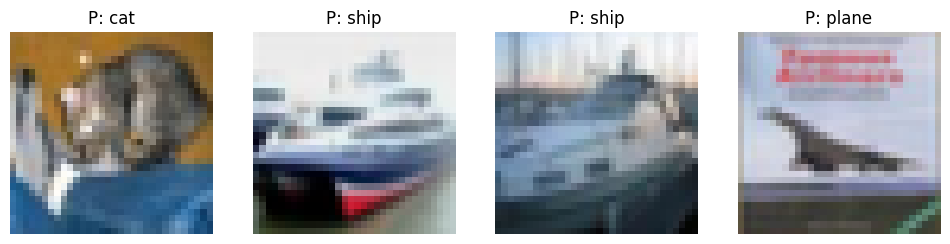

In [35]:
#images
classes = (
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):

    img = images[i].cpu() / 2 + 0.5   # CPU-ya salmaq vacibdir

    npimg = img.numpy()

    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))

    axes[i].set_title(f"P: {classes[predicted[i].item()]}")

    axes[i].axis("off")

plt.show()

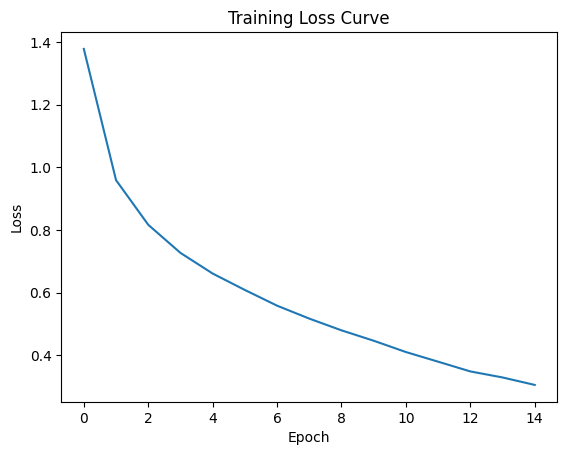

In [37]:
#Loss plot
plt.plot(train_loss)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

# Training Loss Curve

The plot below shows how the training loss changed across 15 epochs during CNN training on the CIFAR10 dataset.

The loss consistently decreases, which indicates that the model is successfully learning meaningful features from the data.

---

## Observation

- Loss starts high (~1.4)
- Rapid decrease in early epochs
- Gradual stabilization after epoch 10
- Final loss reaches around ~0.3

This confirms that the training process was stable and effective.